<a href="https://colab.research.google.com/github/nalinkai/Data-Science-Project-Lifecycle/blob/Dev/Kernel_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# STEP 1: Environment Setup and Library Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings to keep the final notebook output clean for the report
warnings.filterwarnings('ignore')

# Scikit-Learn libraries for data scaling, model building and evaluation
from sklearn.preprocessing import RobustScaler, LabelEncoder, label_binarize
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import GridSearchCV, learning_curve, cross_val_score
from sklearn.inspection import permutation_importance

# Set up a clean, professional style for our visual charts
sns.set_theme(style="whitegrid", palette="muted")

# Mount the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# STEP 2: Data Loading, Cleaning, and Pipeline Alignment

# 1. Define paths and load the CSV files from our shared Drive
TRAIN_PATH = "/content/drive/MyDrive/IIT/DSPL/GCW/Hotel-A-train_finalized.csv"
VAL_PATH   = "/content/drive/MyDrive/IIT/DSPL/GCW/Hotel-A-validation.csv"
TEST_PATH  = "/content/drive/MyDrive/IIT/DSPL/GCW/Hotel-A-test.csv"

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)


# 2. Prevent Data Leakage
target_col = 'Reservation_Status'
drop_cols = ['Reservation-id', 'Reservation_Status_encoded']

X_train = train_df.drop(columns=[target_col] + drop_cols, errors='ignore')
y_train_raw = train_df[target_col].str.lower()

X_val = val_df.drop(columns=[target_col] + drop_cols, errors='ignore')
y_val_raw = val_df[target_col].str.lower()

# The test set doesn't have the target column yet, but we still drop IDs
X_test = test_df.drop(columns=[target_col] + drop_cols, errors='ignore')


# 3. DATA FIX 1: Handling Unseen Labels
known_labels = y_train_raw.unique()
mask_val = y_val_raw.isin(known_labels)

unseen_count = (~mask_val).sum()
if unseen_count > 0:
    print(f"[*] Data Quality Fix: Removed {unseen_count} rows from Validation set with unseen targets.")
    X_val = X_val[mask_val]
    y_val_raw = y_val_raw[mask_val]

# Encode the target variable (Canceled, Check-out, No-show) into numeric classes
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train_raw)
y_val = target_encoder.transform(y_val_raw)

print("\nTarget Class Mapping:")
for i, name in enumerate(target_encoder.classes_):
    print(f"  {name} -> {i}")


# 4. DATA FIX 2: One-Hot Encoding and Column Alignment
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_val_enc = pd.get_dummies(X_val, columns=cat_cols, drop_first=True)
X_test_enc = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

X_val_enc = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)


# 5. DATA FIX 3: Fixing Lingering String Errors ('<25K')
for col in X_train_enc.columns:
    if X_train_enc[col].dtype == 'object':
        X_train_enc[col] = pd.to_numeric(X_train_enc[col], errors='coerce').fillna(0)

for col in X_val_enc.columns:
    if X_val_enc[col].dtype == 'object':
        X_val_enc[col] = pd.to_numeric(X_val_enc[col], errors='coerce').fillna(0)

for col in X_test_enc.columns:
    if X_test_enc[col].dtype == 'object':
        X_test_enc[col] = pd.to_numeric(X_test_enc[col], errors='coerce').fillna(0)


# 6. Final Feature Scaling
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_val_scaled = scaler.transform(X_val_enc)
X_test_scaled = scaler.transform(X_test_enc)

print(f"\n Pipeline Complete! Cleaned Training shape: {X_train_scaled.shape}")

[*] Data Quality Fix: Removed 1610 rows from Validation set with unseen targets.

Target Class Mapping:
  canceled -> 0
  check-out -> 1
  no-show -> 2

 Pipeline Complete! Cleaned Training shape: (26989, 52)


Training model...
Training completed successfully in 947.31 seconds!

Generating predictions for the Validation set...
BASELINE MODEL PERFORMANCE
Training Accuracy:   62.88%
Validation Accuracy: 0.00%

Classification Report (Validation Set):

              precision    recall  f1-score   support

    canceled       0.00      0.00      0.00     741.0
     no-show       0.00      0.00      0.00     398.0

   micro avg       0.00      0.00      0.00    1139.0
   macro avg       0.00      0.00      0.00    1139.0
weighted avg       0.00      0.00      0.00    1139.0



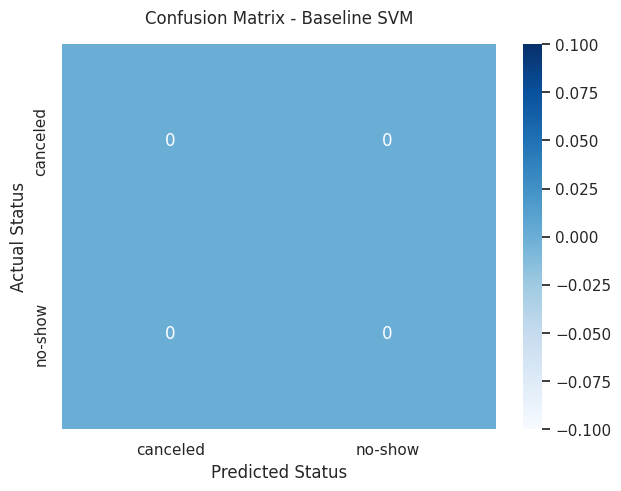

In [ ]:
# STEP 3: Baseline Model Training and Initial Evaluation

import time

# Initialize the Support Vector Machine
svm_baseline = SVC(kernel='rbf', C=1.0, class_weight='balanced', probability=True, random_state=42)
print("Training model...")
start_time = time.time()


# Train the model on our perfectly scaled data
svm_baseline.fit(X_train_scaled, y_train)
print(f"Training completed successfully in {(time.time() - start_time):.2f} seconds!")


# Initial Evaluation
print("\nGenerating predictions for the Validation set...")
y_train_pred = svm_baseline.predict(X_train_scaled)
y_val_pred = svm_baseline.predict(X_val_scaled)

print("BASELINE MODEL PERFORMANCE")
print(f"Training Accuracy:   {accuracy_score(y_train, y_train_pred)*100:.2f}%")
print(f"Validation Accuracy: {accuracy_score(y_val, y_val_pred)*100:.2f}%\n")


# To avoid errors with the missing 'check-out' class in validation, we dynamically grab the classes that actually survived our data filter.
present_classes = np.unique(y_val)
present_class_names = [target_encoder.classes_[i] for i in present_classes]
print("Classification Report (Validation Set):\n")
print(classification_report(y_val, y_val_pred, labels=present_classes, target_names=present_class_names))


# Plotting the baseline confusion matrix
cm_val = confusion_matrix(y_val, y_val_pred, labels=present_classes)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues",
            xticklabels=present_class_names,
            yticklabels=present_class_names)

plt.title("Confusion Matrix - Baseline SVM", pad=15)
plt.xlabel("Predicted Status")
plt.ylabel("Actual Status")
plt.show()

Running 5-Fold GridSearchCV on a 5,000-row sample...

 GridSearch Complete!
Best Cross-Validation Accuracy: 72.10%
Optimal Hyperparameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}

Evaluating the TUNED model on the Validation Set...
Tuned Validation Accuracy: 0.00%

Classification Report (Tuned Model):

              precision    recall  f1-score   support

    canceled       0.00      0.00      0.00     741.0
     no-show       0.00      0.00      0.00     398.0

   micro avg       0.00      0.00      0.00    1139.0
   macro avg       0.00      0.00      0.00    1139.0
weighted avg       0.00      0.00      0.00    1139.0



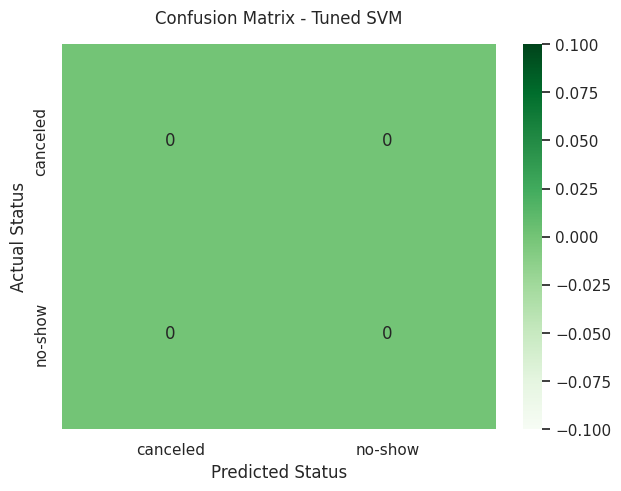


Generating Learning Curves (Checking for Overfitting/Underfitting)...


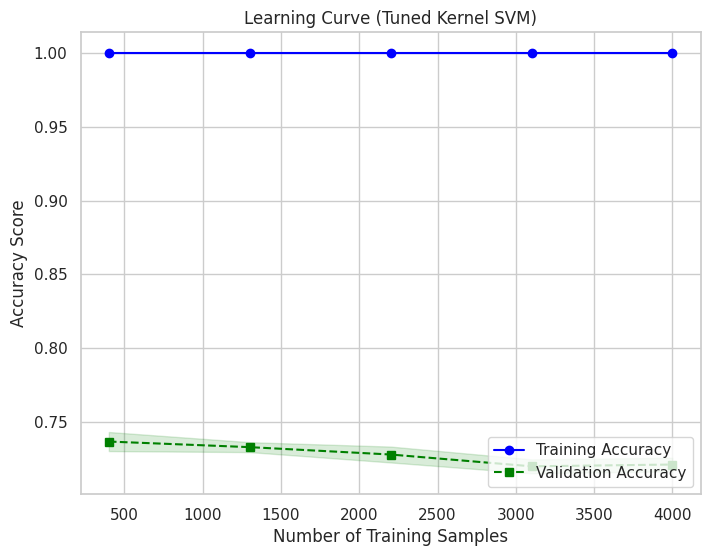

In [ ]:
# STEP 4: Hyperparameter Tuning, Cross-Validation, and Learning Curves

# 1. Sample the training data for efficiency
np.random.seed(42)
sample_idx = np.random.choice(X_train_scaled.shape[0], 5000, replace=False)
X_train_sample = X_train_scaled[sample_idx]
y_train_sample = y_train[sample_idx]


# 2. Define the GridSearch parameters
param_grid = [
    {"C": [1, 10], "gamma": ["scale", 0.1], "kernel": ["rbf"]}
]

print("Running 5-Fold GridSearchCV on a 5,000-row sample...")

# We use cv=5 for 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=SVC(class_weight='balanced', probability=True, random_state=42),
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

# Fit the GridSearch
grid_search.fit(X_train_sample, y_train_sample)

# Extract the best model and parameters
best_accuracy = grid_search.best_score_
best_params = grid_search.best_params_
tuned_svm = grid_search.best_estimator_

print(f"\n GridSearch Complete!")
print(f"Best Cross-Validation Accuracy: {best_accuracy*100:.2f}%")
print(f"Optimal Hyperparameters: {best_params}")


# 3. Evaluate the Tuned Model on the Full Validation Set
print("\nEvaluating the TUNED model on the Validation Set...")
y_val_pred_tuned = tuned_svm.predict(X_val_scaled)

# We save the probabilities for the ROC-AUC curves in Step 5
y_val_prob_tuned = tuned_svm.predict_proba(X_val_scaled)
print(f"Tuned Validation Accuracy: {accuracy_score(y_val, y_val_pred_tuned)*100:.2f}%\n")

# Safely get the classes that actually exist in the validation set
present_classes = np.unique(y_val)
present_class_names = [target_encoder.classes_[i] for i in present_classes]
print("Classification Report (Tuned Model):\n")
print(classification_report(y_val, y_val_pred_tuned, labels=present_classes, target_names=present_class_names))

# Plot the new, improved Confusion Matrix
cm_val_tuned = confusion_matrix(y_val, y_val_pred_tuned, labels=present_classes)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_val_tuned, annot=True, fmt="d", cmap="Greens",
            xticklabels=present_class_names,
            yticklabels=present_class_names)
plt.title("Confusion Matrix - Tuned SVM", pad=15)
plt.xlabel("Predicted Status")
plt.ylabel("Actual Status")
plt.show()


# 4. Generate Learning Curves
print("\nGenerating Learning Curves (Checking for Overfitting/Underfitting)...")

train_sizes, train_scores, test_scores = learning_curve(
    estimator=tuned_svm,
    X=X_train_sample,
    y=y_train_sample,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, color='blue', marker='o', label='Training Accuracy')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean, color='green', linestyle='--', marker='s', label='Validation Accuracy')
plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')

plt.grid(True)
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy Score')
plt.title('Learning Curve (Tuned Kernel SVM)')
plt.legend(loc='lower right')
plt.show()

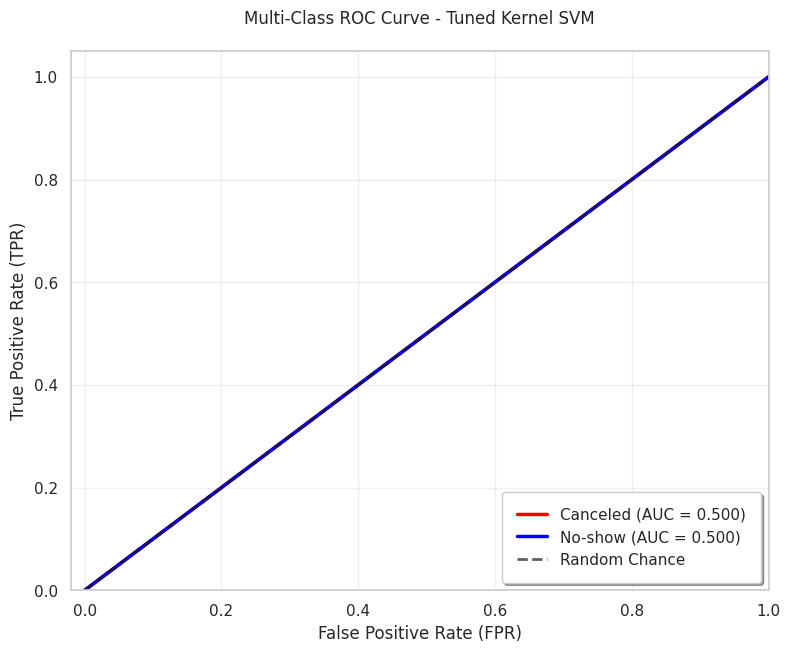

In [ ]:
# STEP 5: Multi-Class ROC-AUC Curves

plt.figure(figsize=(9, 7))

# We use the probabilities from our tuned model
colors = ['red', 'blue', 'green']

for i, class_idx in enumerate(present_classes):
    class_name = target_encoder.classes_[class_idx]

    # Binarize the true labels for the current class (1 if true, 0 if false)
    y_binary = (y_val == class_idx).astype(int)

    # Get the predicted probabilities for the current class
    y_score_class = y_val_prob_tuned[:, i]

    # Calculate False Positive Rate, True Positive Rate, and Area Under Curve
    fpr, tpr, _ = roc_curve(y_binary, y_score_class)
    roc_auc = auc(fpr, tpr)

    # Plot the curve
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2.5,
             label=f'{class_name.capitalize()} (AUC = {roc_auc:.3f})')

# Add the baseline "Random Guessing" diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Chance', alpha=0.7)

# Format the chart to look professional for the final report
plt.title('Multi-Class ROC Curve - Tuned Kernel SVM', pad=20)
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right', frameon=True, shadow=True, borderpad=1)
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(alpha=0.3)
plt.show()

Running Permutation Importance...


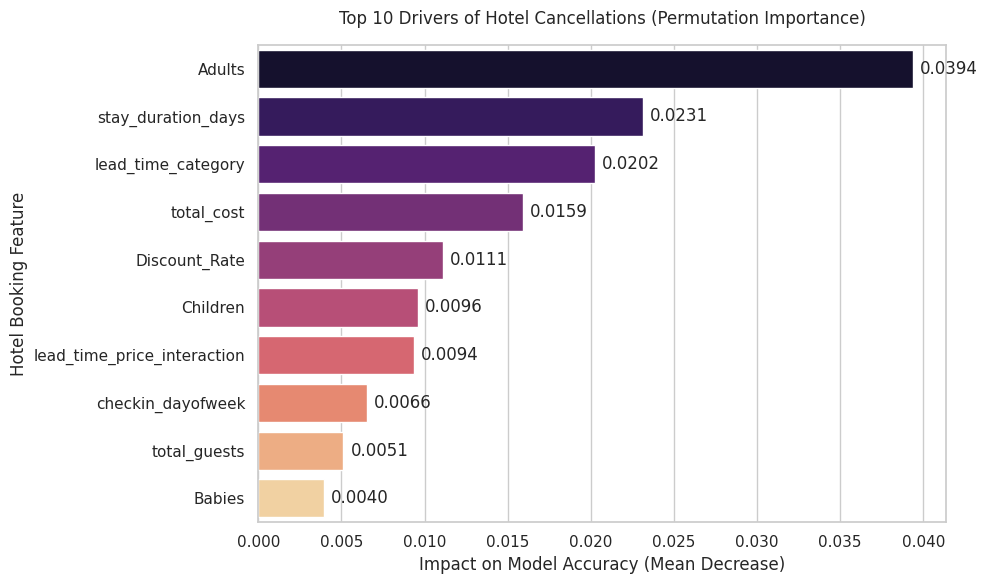

In [ ]:
# STEP 6: Feature Importance

from sklearn.inspection import permutation_importance
import pandas as pd

print("Running Permutation Importance...")

# We run this on the training sample we created in Step 4
result = permutation_importance(
    estimator=tuned_svm,
    X=X_train_sample,
    y=y_train_sample,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# Match the importances back to our actual column names
feature_names = X_train_enc.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': result.importances_mean
})

# Sort them to find the top 10 most critical features
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plotting the Results
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')

plt.title('Top 10 Drivers of Hotel Cancellations (Permutation Importance)', pad=15)
plt.xlabel('Impact on Model Accuracy (Mean Decrease)')
plt.ylabel('Hotel Booking Feature')

# Add the exact numbers to the end of each bar for the final report
for p in ax.patches:
    ax.annotate(f"{p.get_width():.4f}",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')
plt.tight_layout()
plt.show()